In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Daksh_Gururkul_IITG_May_2025/22_SVMs/wine_fraud.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,Legit,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,Legit,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,Legit,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,red


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   object 
 12  type                  6497 non-null   object 
dtypes: float64(11), object(2)
memory usage: 660.0+ KB


# EDA

In [7]:
df['quality'].unique()

array(['Legit', 'Fraud'], dtype=object)

In [8]:
df['type'].unique()

array(['red', 'white'], dtype=object)

<Axes: xlabel='type', ylabel='count'>

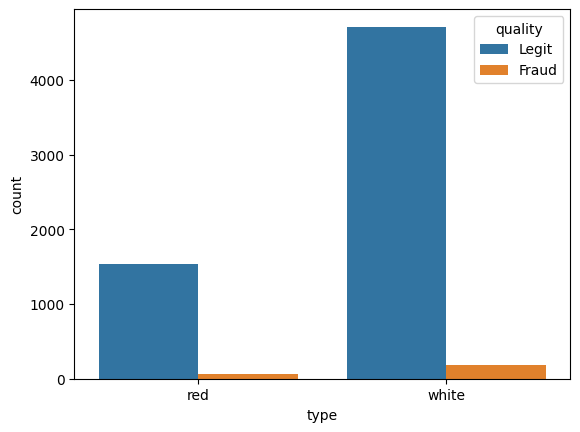

In [9]:
sns.countplot(x='type',hue='quality',data=df)

In [12]:
reds = df[df['type'] == 'red']

In [13]:
whites = df[df['type'] == 'white']

In [21]:
print(f"Percentage of fraud in Red Wines : {np.round(len(reds[reds['quality'] == 'Fraud'])*100/len(reds),2)}")
print(f"Percentage of fraud in White Wines : {np.round(len(whites[whites['quality'] == 'Fraud'])*100/len(whites),2)}")

Percentage of fraud in Red Wines : 3.94
Percentage of fraud in White Wines : 3.74


In [24]:
df['Fraud'] = df['quality'].map({'Legit':0,
                   'Fraud':1})

<Axes: >

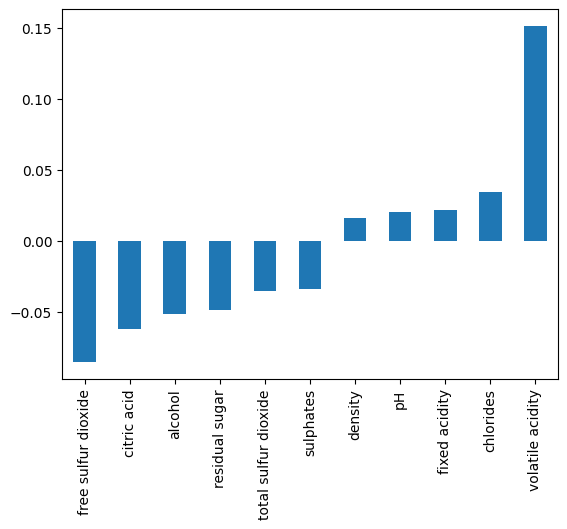

In [31]:
df.corr(numeric_only=True)['Fraud'][:-1].sort_values().plot(kind='bar')

# Machine Learning Model

In [32]:
df.head(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type,Fraud
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,red,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,Legit,red,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,Legit,red,0


In [34]:
df['type'] = pd.get_dummies(df['type'],drop_first=True)

In [35]:
X = df.drop(['quality','Fraud'],axis=1)
y = df['quality']

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.1,random_state=101)

In [38]:
from sklearn.preprocessing import StandardScaler

In [39]:
sc = StandardScaler()

In [40]:
sc_X_train = sc.fit_transform(X_train)
sc_X_test = sc.transform(X_test)

In [55]:
from sklearn.svm import SVC

In [43]:
svc = SVC(class_weight='balanced')

In [44]:
#Grid Search

param_grid = {'C':[0.001,0.01,0.1,0.5,0.8,1],
              'gamma':['scale','auto']}

In [45]:
from sklearn.model_selection import GridSearchCV

In [46]:
grid = GridSearchCV(svc,param_grid)

In [47]:
grid.fit(sc_X_train,y_train)

GridSearchCV(estimator=SVC(class_weight='balanced'),
             param_grid={'C': [0.001, 0.01, 0.1, 0.5, 0.8, 1],
                         'gamma': ['scale', 'auto']})

In [48]:
grid.best_params_

{'C': 1, 'gamma': 'auto'}

In [49]:
from sklearn.metrics import confusion_matrix, classification_report

In [50]:
grid_pred = grid.predict(sc_X_test)
grid_pred

array(['Legit', 'Fraud', 'Legit', 'Legit', 'Fraud', 'Legit', 'Legit',
       'Legit', 'Fraud', 'Legit', 'Fraud', 'Legit', 'Legit', 'Legit',
       'Legit', 'Legit', 'Legit', 'Legit', 'Legit', 'Legit', 'Legit',
       'Legit', 'Legit', 'Legit', 'Legit', 'Legit', 'Legit', 'Legit',
       'Legit', 'Legit', 'Fraud', 'Fraud', 'Fraud', 'Legit', 'Legit',
       'Legit', 'Fraud', 'Legit', 'Fraud', 'Legit', 'Legit', 'Legit',
       'Legit', 'Legit', 'Legit', 'Fraud', 'Legit', 'Legit', 'Fraud',
       'Legit', 'Fraud', 'Legit', 'Legit', 'Legit', 'Legit', 'Legit',
       'Legit', 'Legit', 'Legit', 'Fraud', 'Legit', 'Legit', 'Legit',
       'Legit', 'Legit', 'Legit', 'Legit', 'Legit', 'Fraud', 'Fraud',
       'Legit', 'Legit', 'Legit', 'Fraud', 'Fraud', 'Legit', 'Legit',
       'Fraud', 'Fraud', 'Legit', 'Legit', 'Legit', 'Legit', 'Legit',
       'Legit', 'Legit', 'Legit', 'Legit', 'Legit', 'Legit', 'Legit',
       'Legit', 'Legit', 'Legit', 'Legit', 'Fraud', 'Legit', 'Legit',
       'Legit', 'Leg

In [51]:
confusion_matrix(y_test,grid_pred)

array([[ 17,  10],
       [ 92, 531]])

In [53]:
print(classification_report(y_test,grid_pred))

              precision    recall  f1-score   support

       Fraud       0.16      0.63      0.25        27
       Legit       0.98      0.85      0.91       623

    accuracy                           0.84       650
   macro avg       0.57      0.74      0.58       650
weighted avg       0.95      0.84      0.88       650

